# Modelo: Support Vector Machine (SVM)
**Dataset:** Sonar – Classificação de Minas vs Rochas  
**Algoritmo:** SVC (scikit-learn)  
**Parâmetros:** kernel=rbf | C=1.0 | gamma=scale  
**Split:** 75% treino / 25% teste | random_state=42  
**Normalização:** StandardScaler

## 1. Importações e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve
)
# Bibliotecas de monitoramento de performance computacional
import time
import tracemalloc
import platform
import psutil
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 2. Carregamento dos Dados

In [2]:
PATH = r"C:\Users\Usuário\Documents\paradigmas-programacao\dataset_1_matriz\sonar_data_matriz.csv"

dataset = pd.read_csv(PATH, header=None)
print("Shape:", dataset.shape)
print("\nDistribuição de classes:")
print(dataset.iloc[:, -1].value_counts())
dataset.head()

Shape: (208, 61)

Distribuição de classes:
60
M    111
R     97
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 3. Pré-processamento e Normalização

In [3]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Codificação: M=1 (Mina), R=0 (Rocha)
y = np.where(y == 'M', 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# SVM é sensível à escala — normalização obrigatória
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Treino : {X_train_s.shape[0]} amostras  |  Teste: {X_test_s.shape[0]} amostras")
print(f"Classes: 0=Rocha, 1=Mina")
print("Normalização: StandardScaler aplicado")

Treino : 156 amostras  |  Teste: 52 amostras
Classes: 0=Rocha, 1=Mina
Normalização: StandardScaler aplicado


## 4. Busca de Hiperparâmetros (GridSearchCV)

Exploração dos principais parâmetros do SVM (C e gamma) usando validação cruzada para encontrar a melhor configuração.

In [4]:
param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_s, y_train)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)
print(f"\nMelhor acurácia CV (GridSearch): {grid_search.best_score_:.4f}")

Melhores parâmetros encontrados:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Melhor acurácia CV (GridSearch): 0.8333


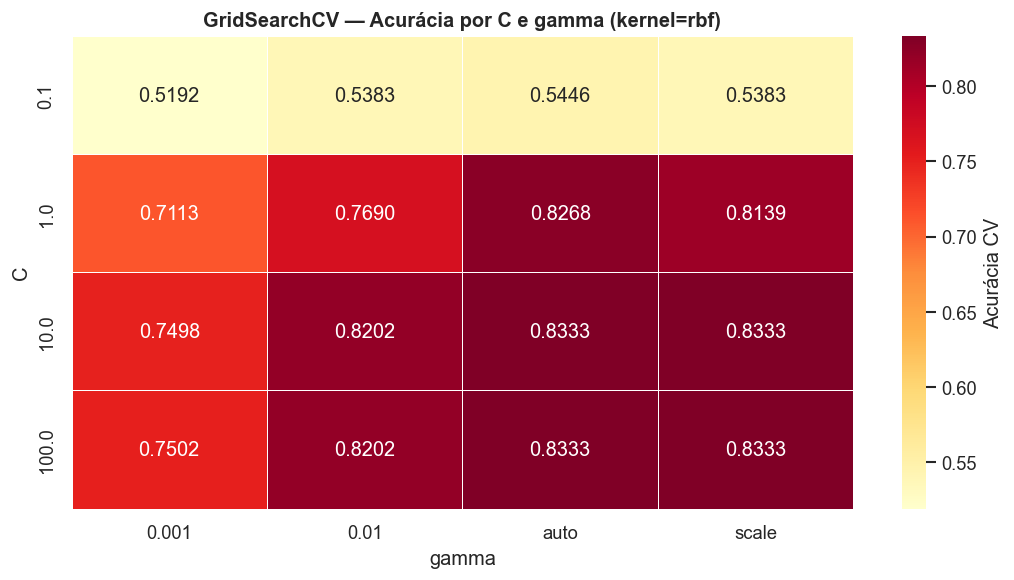

In [5]:
# Visualização do impacto de C e gamma (kernel=rbf)
results_df = pd.DataFrame(grid_search.cv_results_)
rbf_results = results_df[results_df['param_kernel'] == 'rbf'].copy()

pivot_data = rbf_results.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Acurácia CV'})
ax.set_title('GridSearchCV — Acurácia por C e gamma (kernel=rbf)', fontweight='bold')
ax.set_xlabel('gamma')
ax.set_ylabel('C')
plt.tight_layout()
plt.savefig('../images/svm/svm_gridsearch.png', bbox_inches='tight')
plt.show()

## 5. Treinamento do Modelo

In [6]:
modelo = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,   # necessário para predict_proba e ROC-AUC
    random_state=42
)

modelo.fit(X_train_s, y_train)
y_pred  = modelo.predict(X_test_s)
y_proba = modelo.predict_proba(X_test_s)[:, 1]

print("Modelo SVM (kernel=rbf, C=1.0, gamma=scale) treinado com sucesso")
print(f"Vetores de suporte: {modelo.n_support_} (classe 0 / classe 1)")

Modelo SVM (kernel=rbf, C=1.0, gamma=scale) treinado com sucesso
Vetores de suporte: [60 64] (classe 0 / classe 1)


## 6. Métricas de Desempenho

In [7]:
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
cv_scores = cross_val_score(modelo, scaler.fit_transform(X), y, cv=5, scoring='accuracy')

metricas = {
    "Acurácia"         : acc,
    "Precisão (Mina)"  : precision,
    "Recall (Mina)"    : recall,
    "F1-Score (Mina)"  : f1,
    "ROC-AUC"          : roc_auc,
    "CV Acurácia (5x)" : cv_scores.mean(),
}

df_metricas = pd.DataFrame(metricas.items(), columns=["Métrica", "Valor"])
df_metricas["Valor"] = df_metricas["Valor"].map(lambda v: f"{v:.4f}")
print("=== MÉTRICAS – SVM ===")
display(df_metricas)

=== MÉTRICAS – SVM ===


,Métrica,Valor
0,Acurácia,0.9038
1,Precisão (Mina),0.9630
2,Recall (Mina),0.8667
3,F1-Score (Mina),0.9123
4,ROC-AUC,0.9682
5,CV Acurácia (5x),0.6393


## 7. Performance Computacional

Métricas de uso de CPU, memória RAM e tempo de execução coletadas durante o treinamento e a inferência do modelo.

In [8]:
# Informações do ambiente
print("=== AMBIENTE DE EXECUÇÃO ===")
print(f"  SO          : {platform.system()} {platform.release()}")
print(f"  Processador : {platform.processor() or platform.machine()}")
print(f"  Núcleos CPU : {psutil.cpu_count(logical=False)} físicos / {psutil.cpu_count()} lógicos")
print(f"  RAM total   : {psutil.virtual_memory().total / 1e9:.2f} GB")
print(f"  Python      : {platform.python_version()}")

# CPU e RAM antes do treino
cpu_antes = psutil.cpu_percent(interval=0.5)
proc      = psutil.Process(os.getpid())
ram_antes = proc.memory_info().rss / 1e6  # MB

# Treino com medição de tempo e memória
tracemalloc.start()
t0_treino = time.perf_counter()

_modelo_perf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
_modelo_perf.fit(X_train_s, y_train)

t1_treino = time.perf_counter()
mem_pico_treino, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()

tempo_treino       = t1_treino - t0_treino
mem_pico_treino_mb = mem_pico_treino / 1e6

# Inferência com medição de tempo
t0_inf = time.perf_counter()
_ = _modelo_perf.predict(X_test_s)
t1_inf = time.perf_counter()
tempo_inferencia  = t1_inf - t0_inf
tempo_por_amostra = tempo_inferencia / len(X_test) * 1000  # ms

# CPU e RAM depois
cpu_depois = psutil.cpu_percent(interval=0.5)
ram_depois = proc.memory_info().rss / 1e6

# Tabela de resultados
df_perf = pd.DataFrame({
    "Métrica": [
        "Tempo de Treino (s)",
        "Tempo de Inferência (s)",
        "Tempo por Amostra (ms)",
        "Pico de Memória — Treino (MB)",
        "RAM do Processo — Antes (MB)",
        "RAM do Processo — Depois (MB)",
        "Delta RAM (MB)",
        "CPU antes do treino (%)",
        "CPU depois do treino (%)",
        "Amostras de Treino",
        "Amostras de Teste",
        "Núcleos lógicos disponíveis",
    ],
    "Valor": [
        f"{tempo_treino:.6f}",
        f"{tempo_inferencia:.6f}",
        f"{tempo_por_amostra:.4f}",
        f"{mem_pico_treino_mb:.4f}",
        f"{ram_antes:.2f}",
        f"{ram_depois:.2f}",
        f"{ram_depois - ram_antes:.2f}",
        f"{cpu_antes:.1f}",
        f"{cpu_depois:.1f}",
        str(len(X_train)),
        str(len(X_test)),
        str(psutil.cpu_count()),
    ]
})

print("\n=== PERFORMANCE COMPUTACIONAL — SVM ===")
display(df_perf)

=== AMBIENTE DE EXECUÇÃO ===
  SO          : Windows 10
  Processador : AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD
  Núcleos CPU : 6 físicos / 12 lógicos
  RAM total   : 16.53 GB
  Python      : 3.11.9

=== PERFORMANCE COMPUTACIONAL — SVM ===


,Métrica,Valor
0,Tempo de Treino (s),0.009780
1,Tempo de Inferência (s),0.000775
2,Tempo por Amostra (ms),0.0149
3,Pico de Memória — Treino (MB),0.0677
4,RAM do Processo — Antes (MB),232.06
5,RAM do Processo — Depois (MB),228.82
6,Delta RAM (MB),-3.24
7,CPU antes do treino (%),11.6
8,CPU depois do treino (%),18.3
9,Amostras de Treino,156


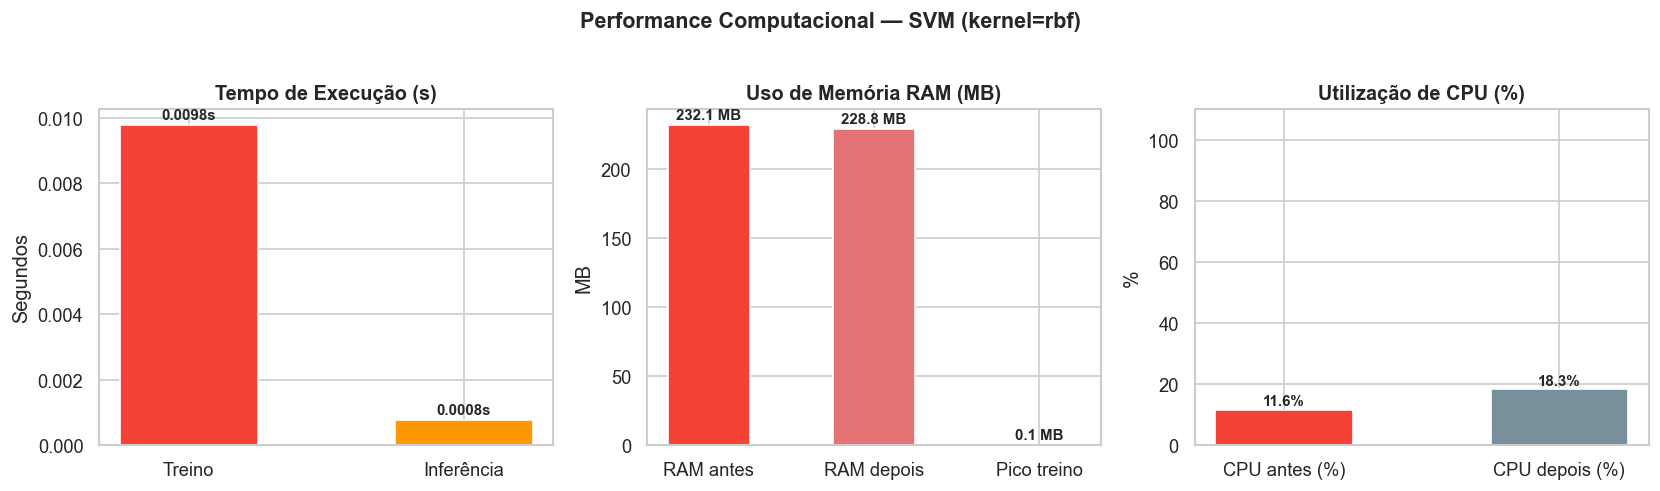

In [9]:
# ── Visualização das métricas de performance ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Tempo
labels_t = ["Treino", "Inferência"]
vals_t   = [tempo_treino, tempo_inferencia]
bars = axes[0].bar(labels_t, vals_t, color=["#F44336", "#FF9800"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_t):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + max(vals_t)*0.01,
                 f"{v:.4f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Tempo de Execução (s)", fontweight="bold")
axes[0].set_ylabel("Segundos")

# 2. Memória RAM
labels_m = ["RAM antes", "RAM depois", "Pico treino"]
vals_m   = [ram_antes, ram_depois, mem_pico_treino_mb]
bars = axes[1].bar(labels_m, vals_m, color=["#F44336", "#E57373", "#FFB74D"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_m):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(vals_m)*0.01,
                 f"{v:.1f} MB", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title("Uso de Memória RAM (MB)", fontweight="bold")
axes[1].set_ylabel("MB")

# 3. CPU
labels_c = ["CPU antes (%)", "CPU depois (%)"]
vals_c   = [cpu_antes, cpu_depois]
bars = axes[2].bar(labels_c, vals_c, color=["#F44336", "#78909C"], edgecolor="white", width=0.5)
for b, v in zip(bars, vals_c):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[2].set_ylim(0, 110)
axes[2].set_title("Utilização de CPU (%)", fontweight="bold")
axes[2].set_ylabel("%")

fig.suptitle("Performance Computacional — SVM (kernel=rbf)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Matriz de Confusão

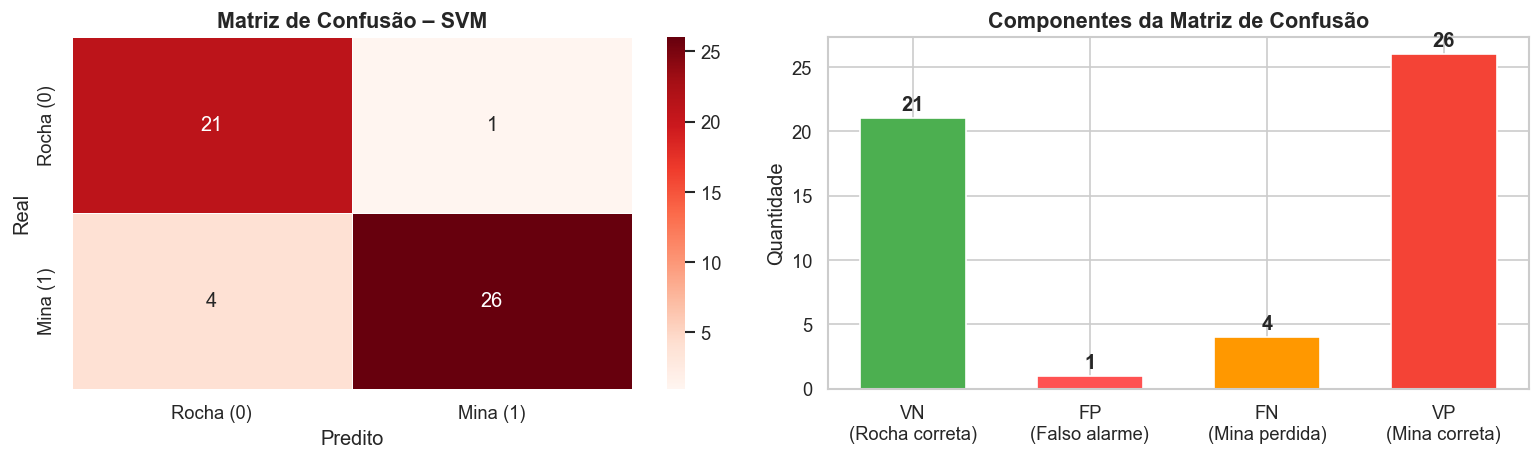


VN=21  FP=1  FN=4  VP=26


In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Rocha (0)', 'Mina (1)'],
            yticklabels=['Rocha (0)', 'Mina (1)'],
            ax=axes[0], linewidths=.5)
axes[0].set_title('Matriz de Confusão – SVM', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Barras de componentes
labels = ['VN\n(Rocha correta)', 'FP\n(Falso alarme)', 'FN\n(Mina perdida)', 'VP\n(Mina correta)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['#4CAF50', '#FF5252', '#FF9800', '#F44336']
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Componentes da Matriz de Confusão', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.savefig('../images/svm/svm_matriz_confusao.png', bbox_inches='tight')
plt.show()

print(f"\nVN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  VP={cm[1,1]}")

## 9. Curva ROC

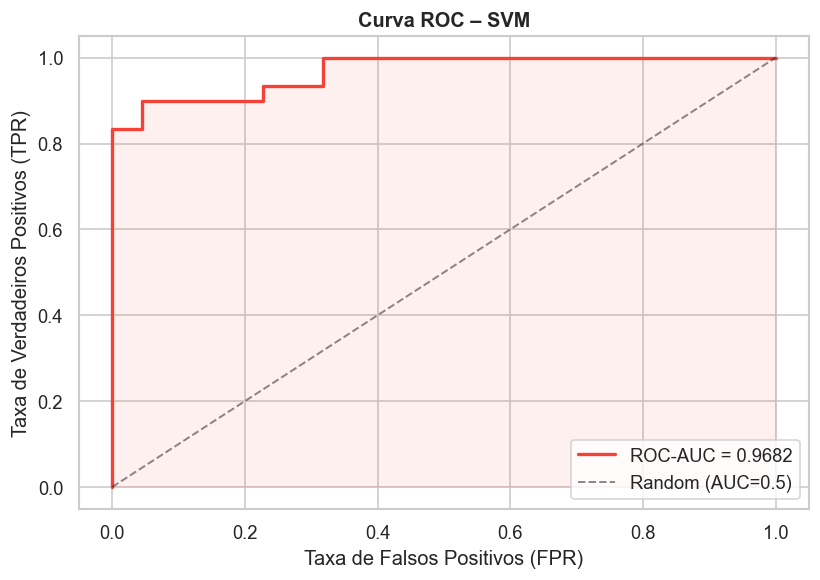

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#F44336', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC=0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#F44336')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.set_title('Curva ROC – SVM', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/svm/svm_roc.png', bbox_inches='tight')
plt.show()

## 10. Relatório de Classificação Completo

In [12]:
print(classification_report(y_test, y_pred, target_names=["Rocha (0)", "Mina (1)"]))

              precision    recall  f1-score   support

   Rocha (0)       0.84      0.95      0.89        22
    Mina (1)       0.96      0.87      0.91        30

    accuracy                           0.90        52
   macro avg       0.90      0.91      0.90        52
weighted avg       0.91      0.90      0.90        52



## 11. Validação Cruzada (5-fold)

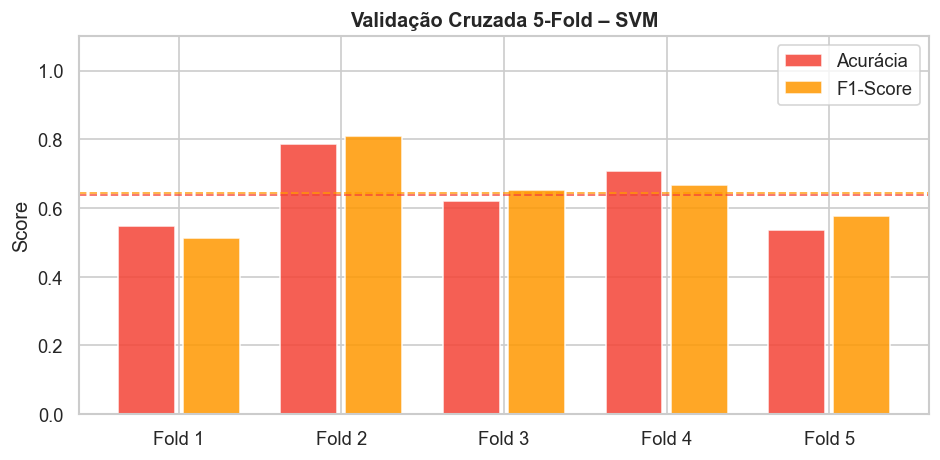

Acurácia CV  → média=0.6393  std=0.0953
F1-Score CV  → média=0.6436   std=0.0992


In [13]:
X_scaled = StandardScaler().fit_transform(X)
cv_acc = cross_val_score(modelo, X_scaled, y, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(modelo, X_scaled, y, cv=5, scoring='f1')

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
ax.bar(x - 0.2, cv_acc, 0.35, label='Acurácia', color='#F44336', alpha=0.85)
ax.bar(x + 0.2, cv_f1,  0.35, label='F1-Score',  color='#FF9800', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Validação Cruzada 5-Fold – SVM', fontweight='bold')
ax.legend()
ax.axhline(cv_acc.mean(), color='#F44336', ls='--', lw=1.2, alpha=0.7)
ax.axhline(cv_f1.mean(),  color='#FF9800', ls='--', lw=1.2, alpha=0.7)
plt.tight_layout()
plt.savefig('../images/svm/svm_cv.png', bbox_inches='tight')
plt.show()

print(f"Acurácia CV  → média={cv_acc.mean():.4f}  std={cv_acc.std():.4f}")
print(f"F1-Score CV  → média={cv_f1.mean():.4f}   std={cv_f1.std():.4f}")

## 12. Sumário Final

In [14]:
sumario = pd.DataFrame({
    "Modelo"                  : ["SVM (kernel=rbf)"],
    "Acurácia"                : [round(acc, 4)],
    "Precisão"                : [round(precision, 4)],
    "Recall"                  : [round(recall, 4)],
    "F1-Score"                : [round(f1, 4)],
    "ROC-AUC"                 : [round(roc_auc, 4)],
    "CV Acurácia (μ)"         : [round(cv_scores.mean(), 4)],
    "Tempo Treino (s)"        : [round(tempo_treino, 6)],
    "Tempo Inferência (s)"    : [round(tempo_inferencia, 6)],
    "Tempo/Amostra (ms)"      : [round(tempo_por_amostra, 4)],
    "Pico Memória Treino (MB)": [round(mem_pico_treino_mb, 4)],
    "Delta RAM (MB)"          : [round(ram_depois - ram_antes, 2)],
})
print("=== SUMÁRIO – SVM ===")
display(sumario)

=== SUMÁRIO – SVM ===


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC,CV Acurácia (μ),Tempo Treino (s),Tempo Inferência (s),Tempo/Amostra (ms),Pico Memória Treino (MB),Delta RAM (MB)
0,SVM (kernel=rbf),0.9038,0.963,0.8667,0.9123,0.9682,0.6393,0.00978,0.000775,0.0149,0.0677,-3.24
